# Phase 2 — Baseline CNN

In [1]:
import sys
sys.path.append('../src')

import torch
from config import SEED, MODELS_DIR, BASELINE_EPOCHS, LEARNING_RATE
from data_loader import get_dataloaders
from models.baseline_cnn import BaselineCNN
from train import set_seed, run_training

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Load data

In [2]:
train_loader, val_loader, test_loader, class_mapping = get_dataloaders()
num_classes = len(class_mapping)

print(f"Classes: {num_classes}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Classes: 38
Train batches: 1188 | Val batches: 255 | Test batches: 256


## 2. Build model

In [3]:
model = BaselineCNN(num_classes=num_classes).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Shape check with a real batch
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad():
    out = model(images)
print(f"Input shape: {images.shape} -> Output shape: {out.shape}")


Total parameters: 2,348,006


g:\Project CNN\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Input shape: torch.Size([32, 3, 128, 128]) -> Output shape: torch.Size([32, 38])


## 3. Train

In [ ]:
history, best_ckpt_path = run_training(
    model=model,
    model_name='baseline',
    epochs=BASELINE_EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    checkpoint_dir=MODELS_DIR / 'baseline',
    lr=LEARNING_RATE,
)


## 4. Review curves

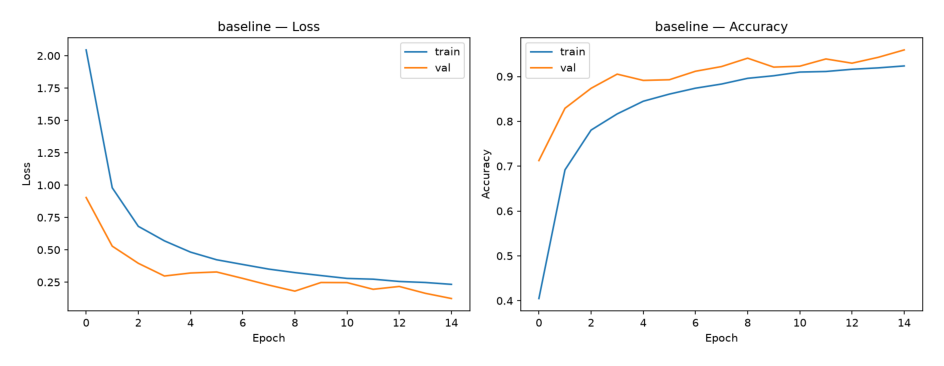

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
from config import PLOTS_DIR

img = Image.open(PLOTS_DIR / 'baseline_curves.png')
plt.figure(figsize=(12, 4.5))
plt.imshow(img)
plt.axis('off')
plt.show()


## 5. Quick test-set check

In [6]:
from train import evaluate
import torch.nn as nn

model.load_state_dict(torch.load(best_ckpt_path))
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")


NameError: name 'best_ckpt_path' is not defined

In [5]:
import sys
sys.path.append("src")
import torch, torch.nn as nn
from config import MODELS_DIR
from data_loader import get_dataloaders
from models.baseline_cnn import BaselineCNN
from train import evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, test_loader, class_mapping = get_dataloaders()

model = BaselineCNN(num_classes=len(class_mapping)).to(device)
model.load_state_dict(torch.load(MODELS_DIR / "baseline" / "baseline_best.pt"))

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

Test loss: 0.1065 | Test accuracy: 0.9643


In [6]:
import json
history = json.load(open("../outputs/logs/baseline_history.json"))
print("Final train acc:", history["train_acc"][-1])
print("Final val acc  :", history["val_acc"][-1])
print("Best val loss  :", min(history["val_loss"]))

Final train acc: 0.9235202779166777
Final val acc  : 0.959281584450732
Best val loss  : 0.12357802882700973
